### Получаем данные

In [ ]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 12/12 [00:15<00:00,  1.26s/it]


### Определяем таргеты для всех моделей

In [3]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 982193/982193 [00:08<00:00, 109992.64it/s]


### Генерируем фичи для всех моделей

In [4]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,0.000159,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.146823,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,0.000214,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.139416,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,0.000275,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.139416,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,0.000443,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.135755,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,0.000956,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.143209,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
982189,1.760026,0.048344,3.727353,4.011458,0.000036,1.760024,0.459141,-0.089697,0.036378,-0.873803,...,0.054713,0.387509,0.408432,0.449990,0.429895,70655.796875,70660.000000,70658.203125,-0.000004,0.000059
982190,1.760026,0.152141,3.743212,4.023640,0.000064,1.760024,0.099844,-2.256626,-0.478329,-19.085814,...,0.054566,0.177292,-3.744710,-0.565011,-0.679765,70655.796875,70660.000000,70658.203125,-0.000052,0.000034
982191,1.760026,0.128172,3.781980,4.076337,0.000142,1.760024,0.191953,-1.281622,-0.222544,-16.094196,...,0.057156,0.207013,-2.919632,-0.355526,-0.429252,70653.296875,70655.703125,70654.601562,0.000129,0.000292
982192,1.663411,0.865047,4.342633,5.030423,0.000066,1.663409,0.022500,-4.756956,-0.821259,-33.342738,...,0.096804,0.290664,-6.153054,-0.753178,-0.728137,70653.398438,70674.000000,70674.000000,0.000034,0.000068


In [5]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [36]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=13,
)

Обучение модели...
[0]	validation_0-rmse:0.00018
[50]	validation_0-rmse:0.00016
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00015
[200]	validation_0-rmse:0.00015
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[650]	validation_0-rmse:0.00015
[700]	validation_0-rmse:0.00015
[750]	validation_0-rmse:0.00015
[800]	validation_0-rmse:0.00015
[850]	validation_0-rmse:0.00015
[900]	validation_0-rmse:0.00015
[950]	validation_0-rmse:0.00015
[1000]	validation_0-rmse:0.00015
[1050]	validation_0-rmse:0.00015
[1100]	validation_0-rmse:0.00015
[1112]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000093
RMSE                     : 0.000150
R²                       : 0.289774
MAE / mean|Δ|            : 0.810830
RMSE / RMSE_base         : 0.842734
mean|Δ| (target)         : 0.000115

------------------------------------------------------------
Directional Accuracy     : 0.641424
Target Pos Ratio         : 0.476071
Profit Factor            : 1.950942
Avg Gain (correct)       : -0.000003
Avg Loss (incorrect)     : 0.000003

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6396, 0.6433)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000126, 0.00149]    0.000227         0.927955    -0.000006      24554
(6.81e-05, 0.000126]    0.000092         0.829396    -0.000003      24554
(4.26e-05, 6.81e-05]    0.000054         0.741468    -0.000003      24554


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


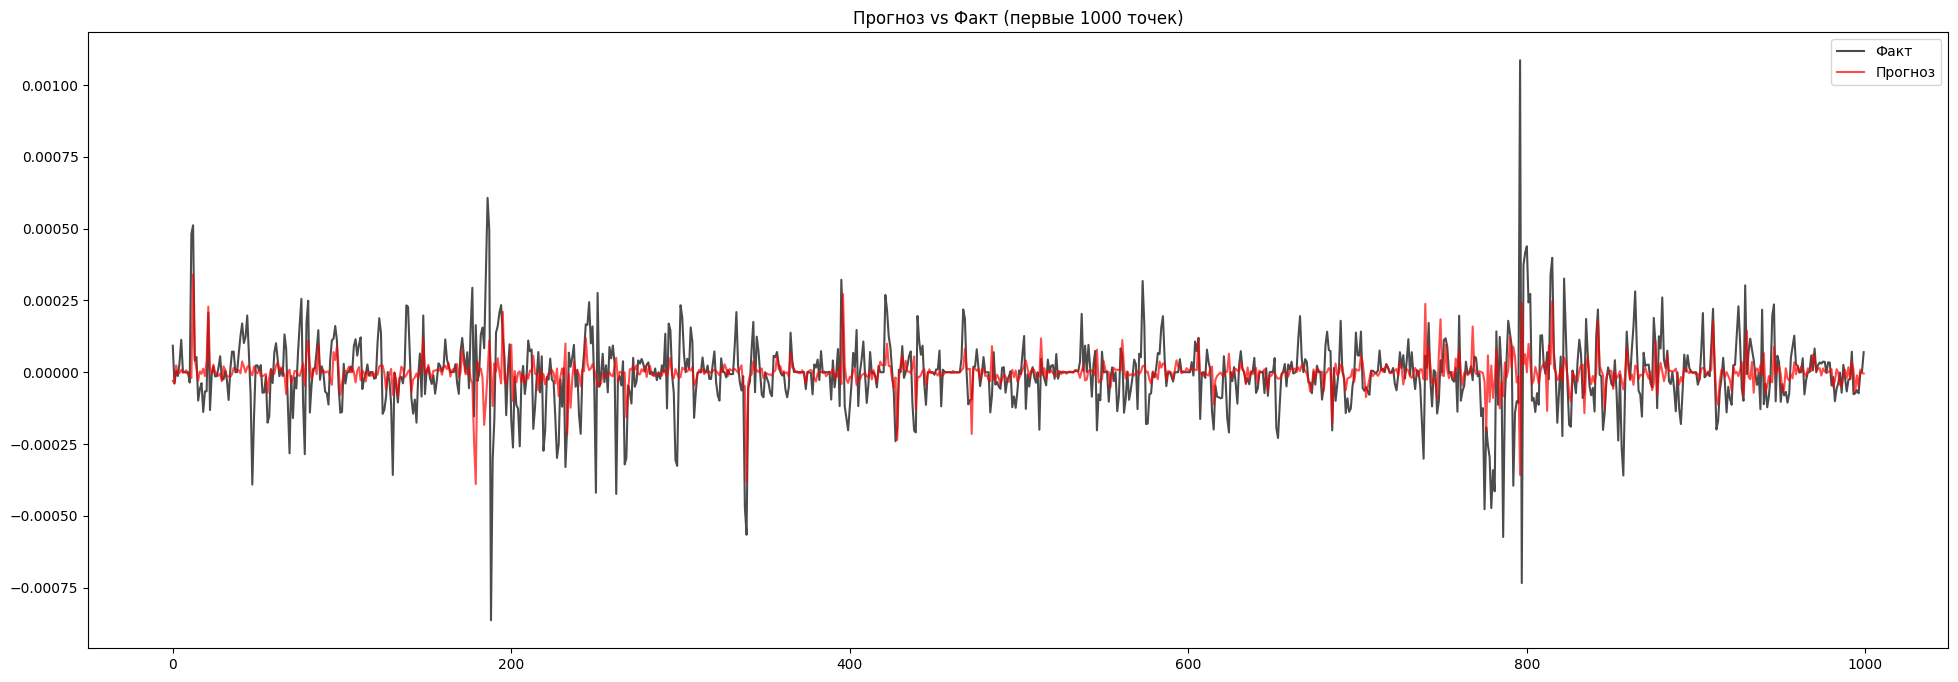

In [37]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [56]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=8,
)

Обучение модели...
[0]	validation_0-rmse:0.00020
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00015
[200]	validation_0-rmse:0.00015
[250]	validation_0-rmse:0.00015
[300]	validation_0-rmse:0.00015
[350]	validation_0-rmse:0.00015
[400]	validation_0-rmse:0.00015
[450]	validation_0-rmse:0.00015
[500]	validation_0-rmse:0.00015
[550]	validation_0-rmse:0.00015
[600]	validation_0-rmse:0.00015
[650]	validation_0-rmse:0.00015
[700]	validation_0-rmse:0.00015
[750]	validation_0-rmse:0.00015
[800]	validation_0-rmse:0.00015
[812]	validation_0-rmse:0.00015
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000101
RMSE                     : 0.000151
R²                       : 0.375535
MAE / mean|Δ|            : 0.600859
RMSE / RMSE_base         : 0.592544
mean|Δ| (target)         : 0.000168

------------------------------------------------------------
Directional Accuracy     : 0.893443
Target Pos Ratio         : 0.893443
Profit Factor            : 41317341611.680672
Avg Gain (correct)       : 0.000188
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.8923, 0.8946)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000328, 0.00196]    0.000446         0.999796     0.000438      24554
(0.000241, 0.000328]    0.000280         0.996172     0.000277      24554
(0.000197, 0.000241]    0.000218         0.984320     0.000213    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


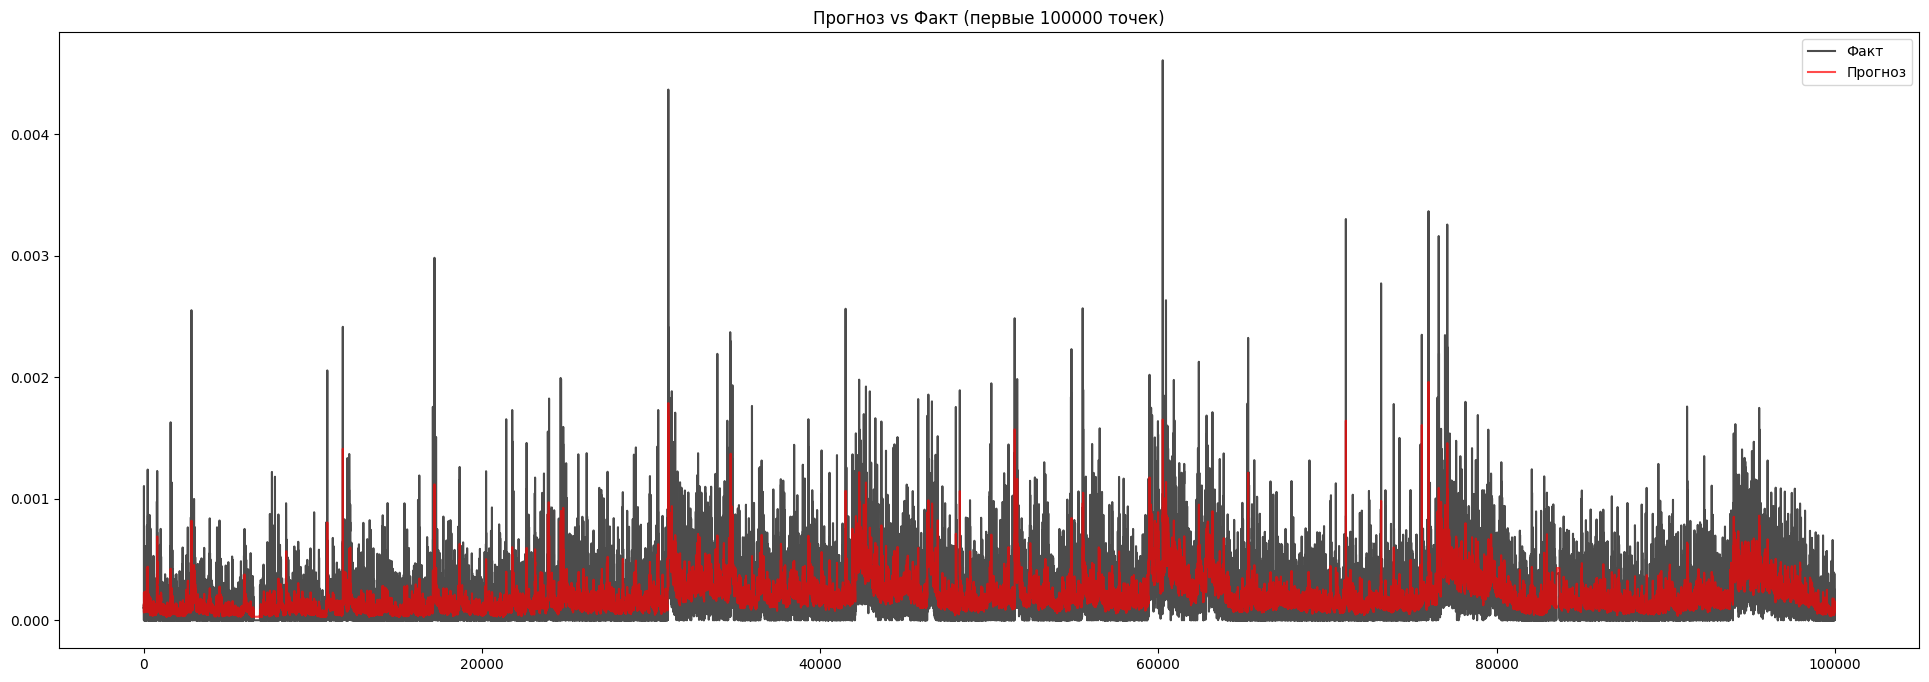

In [57]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)